In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

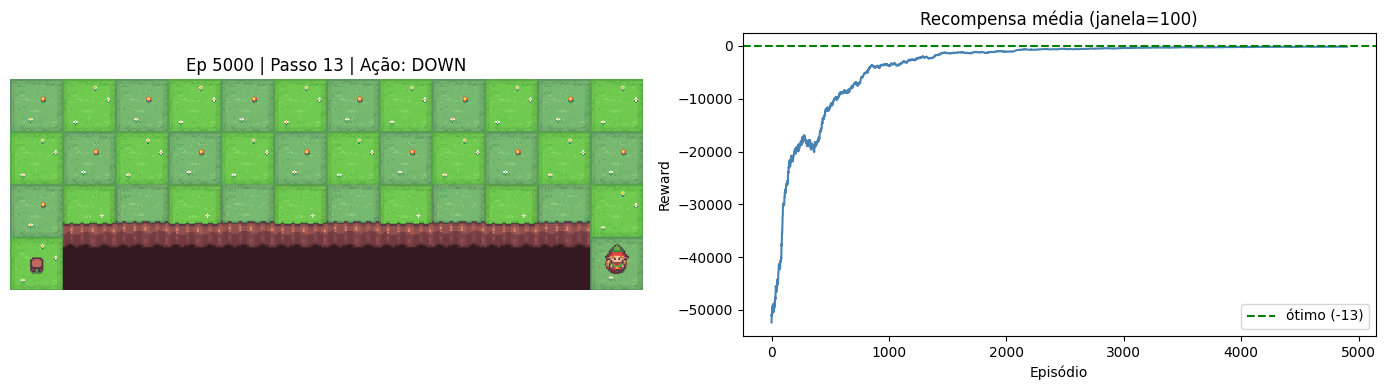

Ep   5000 | epsilon: 0.223 | reward médio: -132.6 | passos: 13


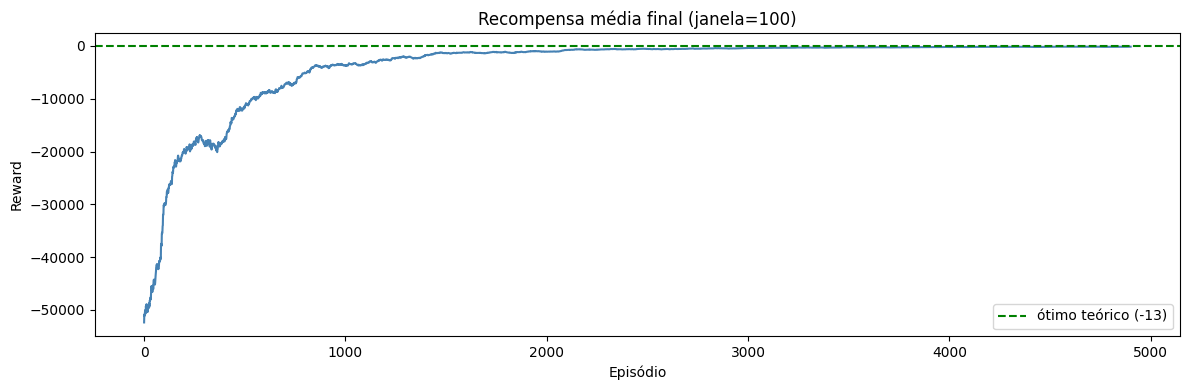


Recompensa média final (últimos 100): -132.6


In [13]:
# --- config ---
EPISODES   = 5000
LR         = 0.5
GAMMA      = 0.99
EPSILON    = 1.0
EPS_DECAY  = 0.9997
EPS_MIN    = 0.01
ROWS, COLS = 4, 12

# mostra cedo no início, depois a cada 1000
SHOW_AT = {1, 10, 50, 100, 500} | set(range(1000, 20001, 1000))

env_render = gym.make("CliffWalking-v1", render_mode="rgb_array")
env_train  = gym.make("CliffWalking-v1")
Q          = np.zeros((env_train.observation_space.n, env_train.action_space.n))

action_names = {0: "UP", 1: "RIGHT", 2: "DOWN", 3: "LEFT"}

def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return env_train.action_space.sample()
    q = Q[state]
    return np.random.choice(np.where(q == q.max())[0])

def show(frame, ep, step, action, rewards):
    """Exibe frame do ambiente + gráfico de aprendizado lado a lado."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.imshow(frame)
    ax1.axis("off")
    ax1.set_title(f"Ep {ep} | Passo {step} | Ação: {action_names[action]}")

    if len(rewards) >= 100:
        moving_avg = np.convolve(rewards, np.ones(100) / 100, mode="valid")
        ax2.plot(moving_avg, color="steelblue")
        ax2.axhline(y=-13, color="green", linestyle="--", label="ótimo (-13)")
        ax2.legend()
    else:
        ax2.plot(rewards, color="steelblue")

    ax2.set_title("Recompensa média (janela=100)")
    ax2.set_xlabel("Episódio")
    ax2.set_ylabel("Reward")

    plt.tight_layout()
    clear_output(wait=True)
    display(fig)
    plt.close(fig)
    time.sleep(0.1)

def render_optimal_route(ep, rewards):
    state, _ = env_render.reset()
    visited   = set()
    steps     = 0

    while state != 47 and state not in visited:
        visited.add(state)
        action                             = np.argmax(Q[state])
        state, _, terminated, truncated, _ = env_render.step(action)
        steps += 1

        show(env_render.render(), ep, steps, action, rewards)

        if terminated or truncated:
            break

    return steps

# --- treino ---
rewards = []
epsilon = EPSILON

for ep in range(1, EPISODES + 1):
    state, _ = env_train.reset()
    done      = False
    total     = 0

    while not done:
        action                                       = choose_action(state, epsilon)
        next_state, reward, terminated, truncated, _ = env_train.step(action)
        done                                          = terminated or truncated

        Q[state, action] += LR * (reward + GAMMA * np.max(Q[next_state]) - Q[state, action])

        state  = next_state
        total += reward

    epsilon = max(EPS_MIN, epsilon * EPS_DECAY)
    rewards.append(total)

    if ep in SHOW_AT:
        steps = render_optimal_route(ep, rewards)
        print(f"Ep {ep:>6} | epsilon: {epsilon:.3f} | reward médio: {np.mean(rewards[-min(100,len(rewards)):]):.1f} | passos: {steps}")

env_train.close()
env_render.close()

# --- gráfico final ---
moving_avg = np.convolve(rewards, np.ones(100) / 100, mode="valid")

plt.figure(figsize=(12, 4))
plt.plot(moving_avg, color="steelblue")
plt.axhline(y=-13, color="green", linestyle="--", label="ótimo teórico (-13)")
plt.title("Recompensa média final (janela=100)")
plt.xlabel("Episódio")
plt.ylabel("Reward")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nRecompensa média final (últimos 100): {np.mean(rewards[-100:]):.1f}")

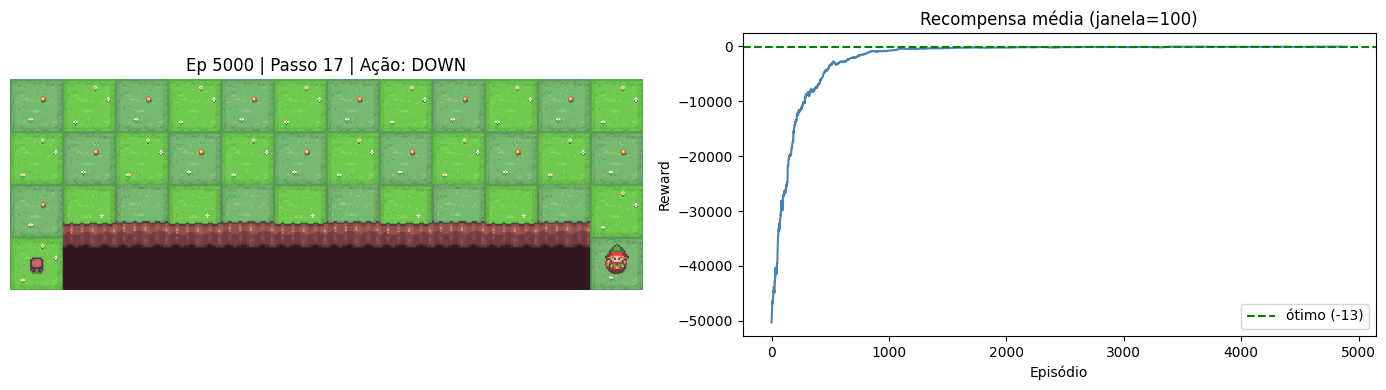

Ep   5000 | epsilon: 0.223 | reward médio: -71.0 | passos: 17


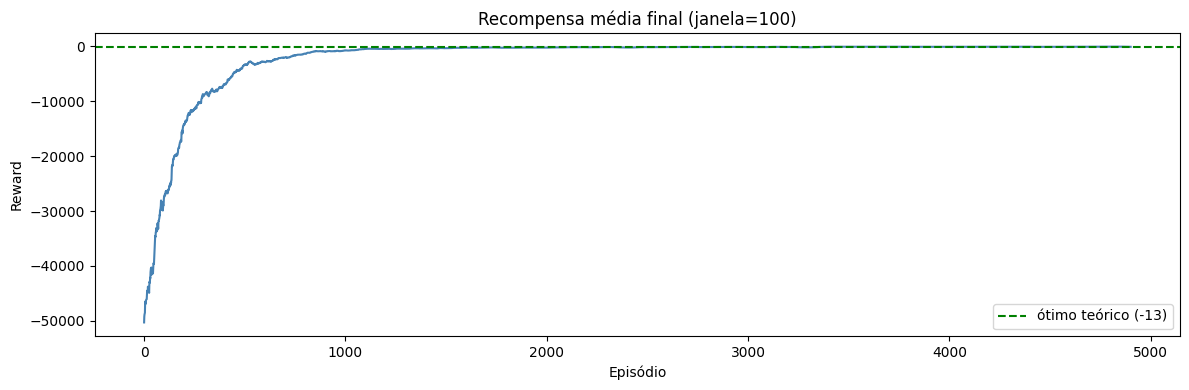


Recompensa média final (últimos 100): -71.0


In [18]:
# --- config ---
EPISODES   = 5000
LR         = 0.5
GAMMA      = 0.99
EPSILON    = 1.0
EPS_DECAY  = 0.9997
EPS_MIN    = 0.01
ROWS, COLS = 4, 12

# mostra cedo no início, depois a cada 1000
SHOW_AT = {1, 10, 50, 100, 500} | set(range(1000, 20001, 1000))

env_render = gym.make("CliffWalking-v1", render_mode="rgb_array")
env_train  = gym.make("CliffWalking-v1")
Q          = np.zeros((env_train.observation_space.n, env_train.action_space.n))

action_names = {0: "UP", 1: "RIGHT", 2: "DOWN", 3: "LEFT"}

def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return env_train.action_space.sample()
    q = Q[state]
    return np.random.choice(np.where(q == q.max())[0])

def show(frame, ep, step, action, rewards):
    """Exibe frame do ambiente + gráfico de aprendizado lado a lado."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.imshow(frame)
    ax1.axis("off")
    ax1.set_title(f"Ep {ep} | Passo {step} | Ação: {action_names[action]}")

    if len(rewards) >= 100:
        moving_avg = np.convolve(rewards, np.ones(100) / 100, mode="valid")
        ax2.plot(moving_avg, color="steelblue")
        ax2.axhline(y=-13, color="green", linestyle="--", label="ótimo (-13)")
        ax2.legend()
    else:
        ax2.plot(rewards, color="steelblue")

    ax2.set_title("Recompensa média (janela=100)")
    ax2.set_xlabel("Episódio")
    ax2.set_ylabel("Reward")

    plt.tight_layout()
    clear_output(wait=True)
    display(fig)
    plt.close(fig)
    time.sleep(0.1)

def render_optimal_route(ep, rewards):
    state, _ = env_render.reset()
    visited   = set()
    steps     = 0

    while state != 47 and state not in visited:
        visited.add(state)
        action                             = np.argmax(Q[state])
        state, _, terminated, truncated, _ = env_render.step(action)
        steps += 1

        show(env_render.render(), ep, steps, action, rewards)

        if terminated or truncated:
            break

    return steps

# --- treino (SARSA) ---
rewards = []
epsilon = EPSILON

for ep in range(1, EPISODES + 1):
    state, _ = env_train.reset()
    action   = choose_action(state, epsilon)  # <<< ação inicial
    done     = False
    total    = 0

    while not done:
        next_state, reward, terminated, truncated, _ = env_train.step(action)
        done = terminated or truncated

        # <<< escolhe próxima ação com a mesma política (SARSA!)
        next_action = choose_action(next_state, epsilon)

        # <<< update SARSA
        Q[state, action] += LR * (
            reward + GAMMA * Q[next_state, next_action] - Q[state, action]
        )

        state  = next_state
        action = next_action
        total += reward

    epsilon = max(EPS_MIN, epsilon * EPS_DECAY)
    rewards.append(total)

    if ep in SHOW_AT:
        steps = render_optimal_route(ep, rewards)
        print(f"Ep {ep:>6} | epsilon: {epsilon:.3f} | reward médio: {np.mean(rewards[-min(100,len(rewards)):]):.1f} | passos: {steps}")

# --- gráfico final ---
moving_avg = np.convolve(rewards, np.ones(100) / 100, mode="valid")

plt.figure(figsize=(12, 4))
plt.plot(moving_avg, color="steelblue")
plt.axhline(y=-13, color="green", linestyle="--", label="ótimo teórico (-13)")
plt.title("Recompensa média final (janela=100)")
plt.xlabel("Episódio")
plt.ylabel("Reward")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nRecompensa média final (últimos 100): {np.mean(rewards[-100:]):.1f}")

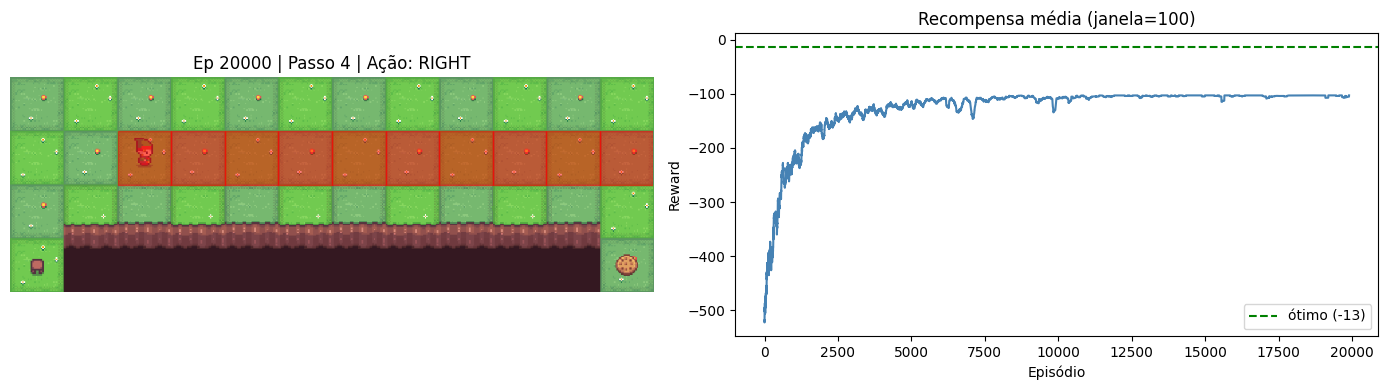

Ep  20000 | epsilon: 0.010 | reward médio: -103.0 | passos: 4


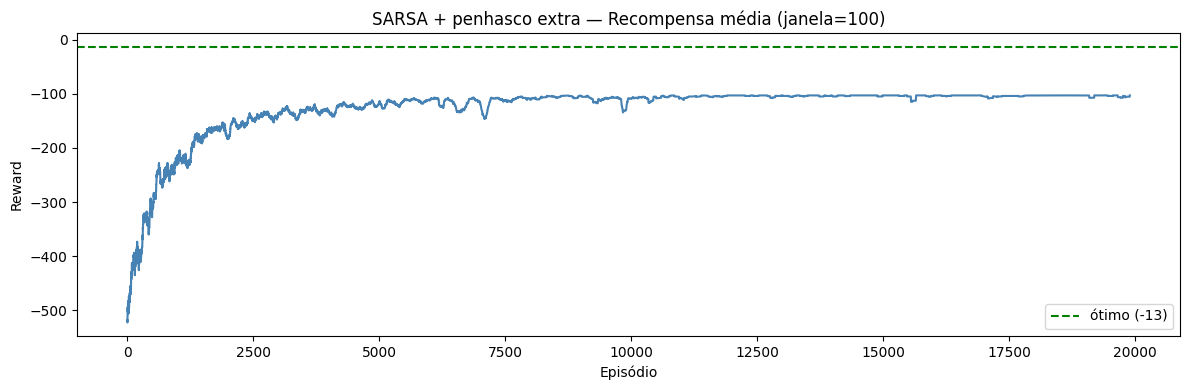


Recompensa média final (últimos 100): -103.0


In [33]:
# --- config ---
EPISODES   = 20000
LR         = 0.5
GAMMA      = 0.99
EPSILON    = 1.0
EPS_DECAY  = 0.9997
EPS_MIN    = 0.01

SHOW_AT = {1, 10, 50, 100, 500} | set(range(1000, 20001, 1000))

ROWS, COLS  = 4, 12
# penhasco extra: row 1, cols 2 até 9
EXTRA_HOLES = set(range(1*COLS + 2, 1*COLS + 12))  # estados 14 a 21

action_names = {0: "UP", 1: "RIGHT", 2: "DOWN", 3: "LEFT"}

class CliffWithHoles(gym.Wrapper):
    def __init__(self, extra_holes, render_mode=None):
        super().__init__(gym.make("CliffWalking-v1", render_mode=render_mode))
        self.extra_holes = extra_holes

    def step(self, action):
        state, reward, terminated, truncated, info = self.env.step(action)
        if state in self.extra_holes:
            return state, -100, True, False, info
        return state, reward, terminated, truncated, info

env_render = CliffWithHoles(EXTRA_HOLES, render_mode="rgb_array")
env_train  = CliffWithHoles(EXTRA_HOLES)
Q          = np.zeros((env_train.observation_space.n, env_train.action_space.n))

def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return env_train.action_space.sample()
    q = Q[state]
    return np.random.choice(np.where(q == q.max())[0])

def overlay_holes(ax, frame, holes):
    """Desenha retângulos vermelhos sobre as células dos buracos extras."""
    h, w    = frame.shape[:2]
    cell_h  = h / ROWS
    cell_w  = w / COLS
    for state in holes:
        row, col = divmod(state, COLS)
        x = col * cell_w
        y = row * cell_h
        ax.add_patch(plt.Rectangle((x, y), cell_w, cell_h,
                                   color="red", alpha=0.5))

def show(frame, ep, step, action, rewards):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.imshow(frame)
    overlay_holes(ax1, frame, EXTRA_HOLES)  # sobrepõe penhasco
    ax1.axis("off")
    ax1.set_title(f"Ep {ep} | Passo {step} | Ação: {action_names[action]}")
    if len(rewards) >= 100:
        ax2.plot(np.convolve(rewards, np.ones(100)/100, mode="valid"), color="steelblue")
        ax2.axhline(y=-13, color="green", linestyle="--", label="ótimo (-13)")
        ax2.legend()
    else:
        ax2.plot(rewards, color="steelblue")
    ax2.set_title("Recompensa média (janela=100)")
    ax2.set_xlabel("Episódio")
    ax2.set_ylabel("Reward")
    plt.tight_layout()
    clear_output(wait=True)
    display(fig)
    plt.close(fig)
    time.sleep(0.1)

def render_optimal_route(ep, rewards):
    state, _ = env_render.reset()
    visited   = set()
    steps     = 0
    while state != 47 and state not in visited:
        visited.add(state)
        action                             = np.argmax(Q[state])
        state, _, terminated, truncated, _ = env_render.step(action)
        steps += 1
        show(env_render.render(), ep, steps, action, rewards)
        if terminated or truncated:
            break
    return steps

# --- treino SARSA ---
rewards = []
epsilon = EPSILON

for ep in range(1, EPISODES + 1):
    state, _ = env_train.reset()
    action   = choose_action(state, epsilon)
    done     = False
    total    = 0

    while not done:
        next_state, reward, terminated, truncated, _ = env_train.step(action)
        done        = terminated or truncated
        next_action = choose_action(next_state, epsilon)

        Q[state, action] += LR * (reward + GAMMA * Q[next_state, next_action] - Q[state, action])

        state  = next_state
        action = next_action
        total += reward

    epsilon = max(EPS_MIN, epsilon * EPS_DECAY)
    rewards.append(total)

    if ep in SHOW_AT:
        steps = render_optimal_route(ep, rewards)
        print(f"Ep {ep:>6} | epsilon: {epsilon:.3f} | reward médio: {np.mean(rewards[-min(100,len(rewards)):]):.1f} | passos: {steps}")

env_train.close()
env_render.close()

# --- gráfico final ---
plt.figure(figsize=(12, 4))
plt.plot(np.convolve(rewards, np.ones(100)/100, mode="valid"), color="steelblue")
plt.axhline(y=-13, color="green", linestyle="--", label="ótimo (-13)")
plt.title("SARSA + penhasco extra — Recompensa média (janela=100)")
plt.xlabel("Episódio")
plt.ylabel("Reward")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nRecompensa média final (últimos 100): {np.mean(rewards[-100:]):.1f}")

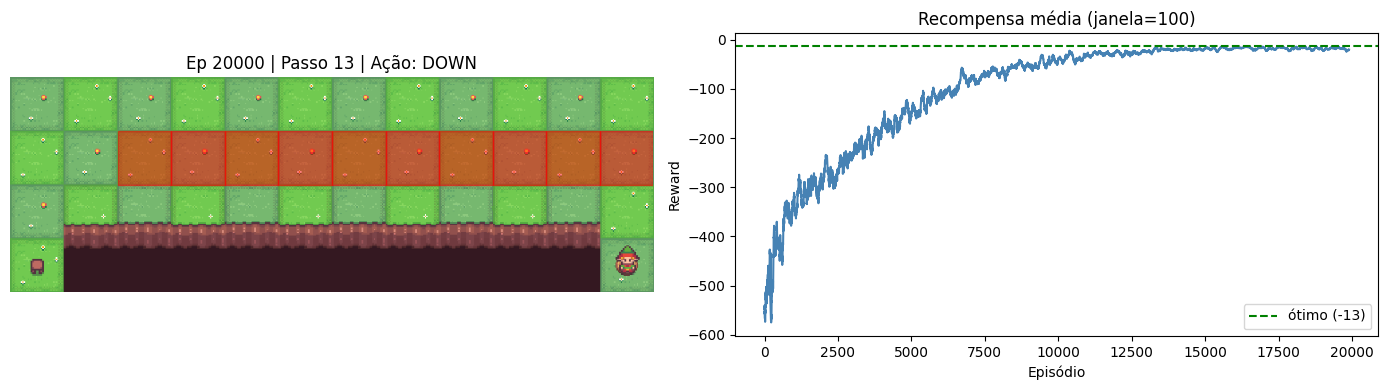

Ep  20000 | epsilon: 0.010 | reward médio: -20.3 | passos: 13


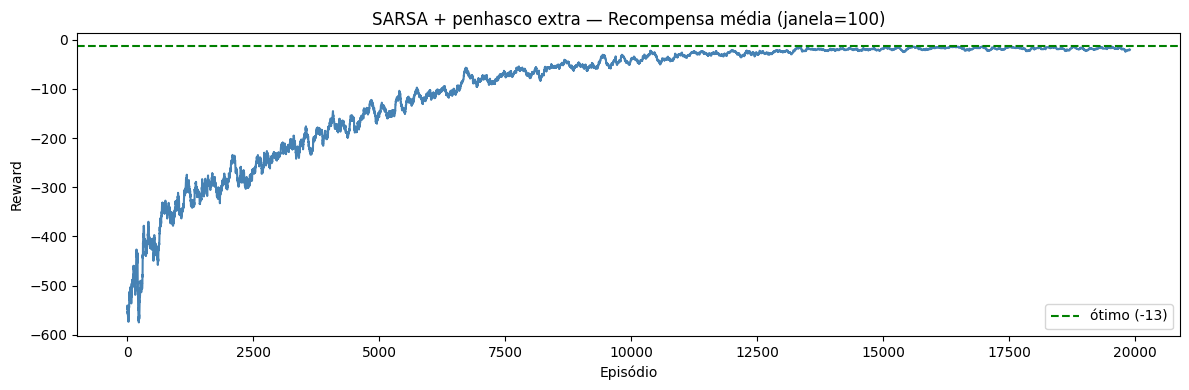


Recompensa média final (últimos 100): -20.3


In [ ]:
# --- config ---
EPISODES   = 20000
LR         = 0.5
GAMMA      = 0.99
EPSILON    = 1.0
EPS_DECAY  = 0.9997
EPS_MIN    = 0.01

SHOW_AT = {1, 10, 50, 100, 500} | set(range(1000, 20001, 1000))

ROWS, COLS  = 4, 12
# penhasco extra: row 1, cols 2 até 9
EXTRA_HOLES = set(range(1*COLS + 2, 1*COLS + 12))  # estados 14 a 21

action_names = {0: "UP", 1: "RIGHT", 2: "DOWN", 3: "LEFT"}

class CliffWithHoles(gym.Wrapper):
    def __init__(self, extra_holes, render_mode=None):
        super().__init__(gym.make("CliffWalking-v1", render_mode=render_mode))
        self.extra_holes = extra_holes

    def step(self, action):
        state, reward, terminated, truncated, info = self.env.step(action)
        if state in self.extra_holes:
            return state, -100, True, False, info
        return state, reward, terminated, truncated, info

env_render = CliffWithHoles(EXTRA_HOLES, render_mode="rgb_array")
env_train  = CliffWithHoles(EXTRA_HOLES)
Q          = np.zeros((env_train.observation_space.n, env_train.action_space.n))

def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return env_train.action_space.sample()
    q = Q[state]
    return np.random.choice(np.where(q == q.max())[0])

def overlay_holes(ax, frame, holes):
    """Desenha retângulos vermelhos sobre as células dos buracos extras."""
    h, w    = frame.shape[:2]
    cell_h  = h / ROWS
    cell_w  = w / COLS
    for state in holes:
        row, col = divmod(state, COLS)
        x = col * cell_w
        y = row * cell_h
        ax.add_patch(plt.Rectangle((x, y), cell_w, cell_h,
                                   color="red", alpha=0.5))

def show(frame, ep, step, action, rewards):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.imshow(frame)
    overlay_holes(ax1, frame, EXTRA_HOLES)  # sobrepõe penhasco
    ax1.axis("off")
    ax1.set_title(f"Ep {ep} | Passo {step} | Ação: {action_names[action]}")
    if len(rewards) >= 100:
        ax2.plot(np.convolve(rewards, np.ones(100)/100, mode="valid"), color="steelblue")
        ax2.axhline(y=-13, color="green", linestyle="--", label="ótimo (-13)")
        ax2.legend()
    else:
        ax2.plot(rewards, color="steelblue")
    ax2.set_title("Recompensa média (janela=100)")
    ax2.set_xlabel("Episódio")
    ax2.set_ylabel("Reward")
    plt.tight_layout()
    clear_output(wait=True)
    display(fig)
    plt.close(fig)
    time.sleep(0.1)

def render_optimal_route(ep, rewards):
    state, _ = env_render.reset()
    visited   = set()
    steps     = 0
    while state != 47 and state not in visited:
        visited.add(state)
        action                             = np.argmax(Q[state])
        state, _, terminated, truncated, _ = env_render.step(action)
        steps += 1
        show(env_render.render(), ep, steps, action, rewards)
        if terminated or truncated:
            break
    return steps

# --- treino Q-learning ---
rewards = []
epsilon = EPSILON

for ep in range(1, EPISODES + 1):
    state, _ = env_train.reset()
    done     = False
    total    = 0

    while not done:
        action = choose_action(state, epsilon)

        next_state, reward, terminated, truncated, _ = env_train.step(action)
        done = terminated or truncated

        # <<< UPDATE Q-LEARNING
        Q[state, action] += LR * (
            reward + GAMMA * np.max(Q[next_state]) - Q[state, action]
        )

        state  = next_state
        total += reward

    epsilon = max(EPS_MIN, epsilon * EPS_DECAY)
    rewards.append(total)

    if ep in SHOW_AT:
        steps = render_optimal_route(ep, rewards)
        print(f"Ep {ep:>6} | epsilon: {epsilon:.3f} | reward médio: {np.mean(rewards[-min(100,len(rewards)):]):.1f} | passos: {steps}")

# --- gráfico final ---
plt.figure(figsize=(12, 4))
plt.plot(np.convolve(rewards, np.ones(100)/100, mode="valid"), color="steelblue")
plt.axhline(y=-13, color="green", linestyle="--", label="ótimo (-13)")
plt.title("Q-Learning + penhasco extra — Recompensa média (janela=100)")
plt.xlabel("Episódio")
plt.ylabel("Reward")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nRecompensa média final (últimos 100): {np.mean(rewards[-100:]):.1f}")